<a href="https://colab.research.google.com/github/harshini-sudharsan/Gauge-Transformed-Imported-Volatility-Quantification/blob/main/final_DY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  Diebold-Yilmaz (2008) Spillover Index
  S&P 500  x  Nifty 50  |  Daily  |  Generalised FEVD
  Period : 2006-01-01  to  2024-01-01

[1/6] Downloading OHLC data ...
      Returns    : (3887, 2)  (2007-09-18 to 2023-12-29)
      Volatility : (3887, 2)

[2/6] Running ADF + KPSS stationarity tests ...

------------------------------------------------------------------
  Stationarity Tests — Log-Returns
------------------------------------------------------------------
  Significance level : 5%
  ADF  H0 : unit root present    (reject => stationary)
  KPSS H0 : series is stationary (reject => non-stationary)
------------------------------------------------------------------

  Series : SP500
    ADF   stat =  -12.4320   p = 0.0000   lags =  24   => stationary
          crit: 1% =  -3.432   5% =  -2.862   10% =  -2.567
    KPSS  stat =    0.2282   p = 0.1000   lags =  16   => stationary
          crit: 1% =   0.739   5% =   0.463   10% =   0.347
    Verdict : I(0)  => OK for VAR

  Series :

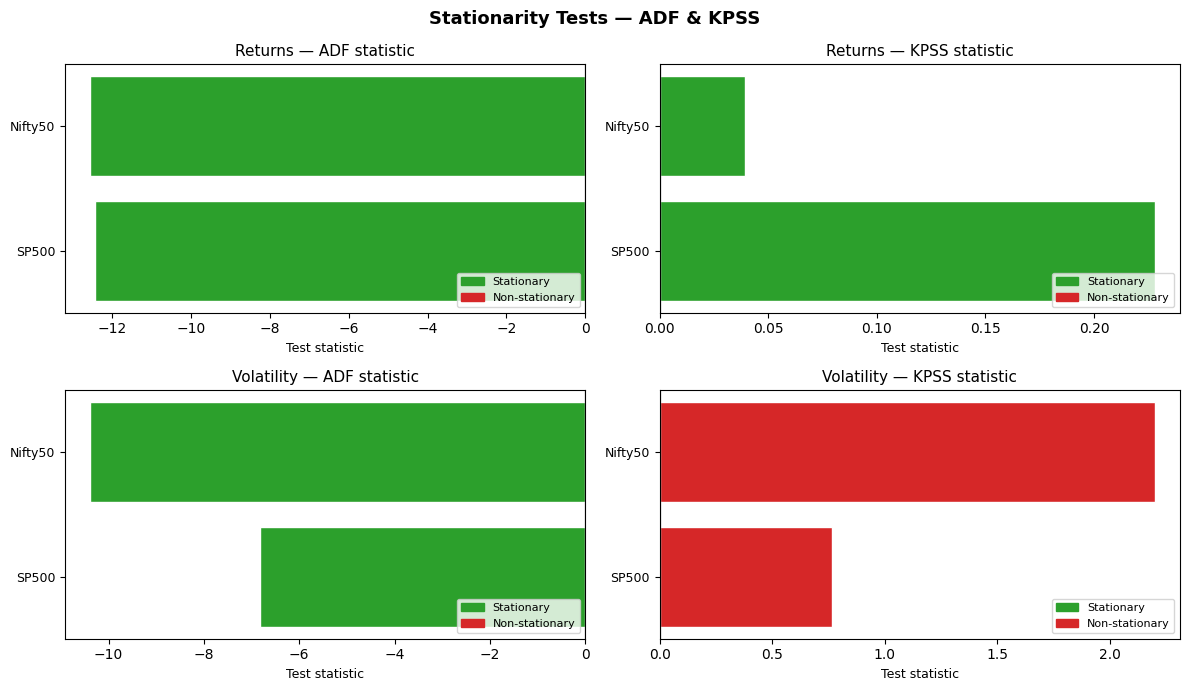

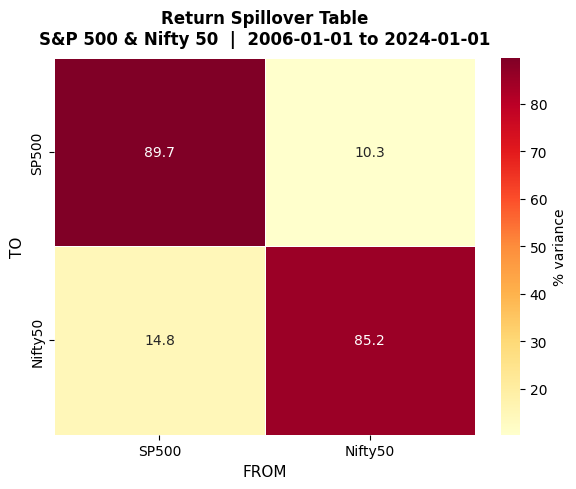

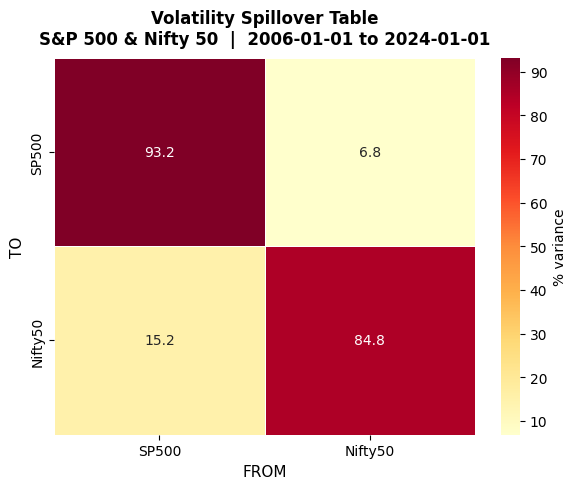

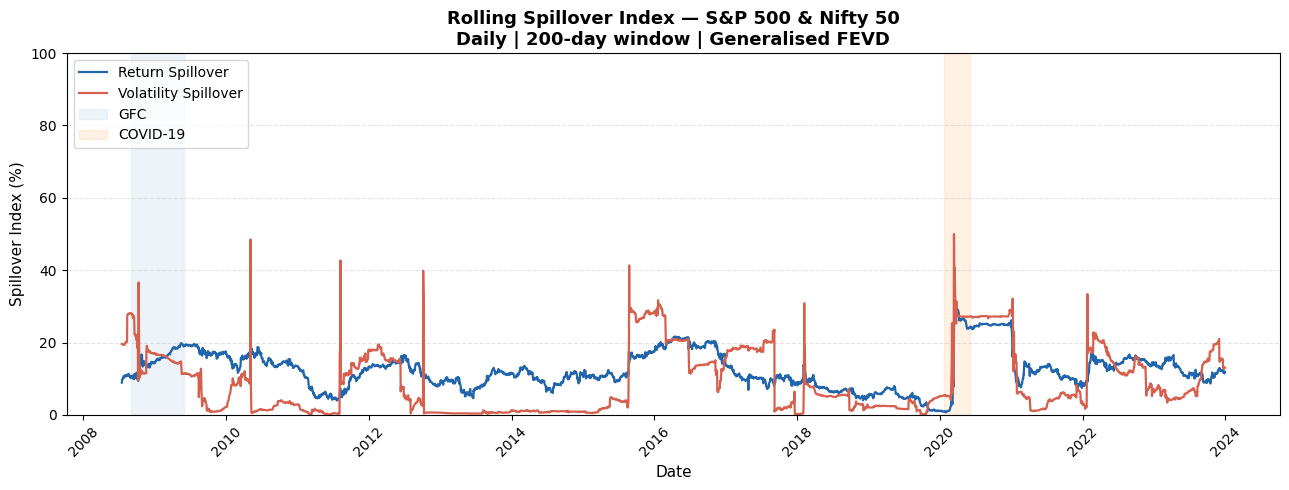


Done.



In [2]:
"""
Diebold-Yilmaz (2008) Spillover Index
Markets : S&P 500  vs  Nifty 50
Frequency: Daily
Window   : ~18 years  (2006-01-01 to 2024-01-01, adjustable)

Methodology follows DY-2008 but uses Generalised FEVD (Pesaran & Shin 1998)
so results are ordering-invariant — no Cholesky ambiguity.

Pipeline
--------
1. Download OHLC data (yfinance)
2. Compute log-returns and Garman-Klass volatility
3. Stationarity tests — ADF + KPSS for every series
   → warn and first-difference any series that fails both tests
4. Full-sample GFEVD spillover tables (returns + volatility)
5. Rolling spillover index (200-day window)
6. All plots saved to disk

Dependencies
------------
pip install yfinance pandas numpy statsmodels matplotlib seaborn
"""

# ── Imports ───────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import yfinance as yf

from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller, kpss


# ── 0. Configuration ──────────────────────────────────────────────────────────
START       = "2006-01-01"
END         = "2024-01-01"
TICKERS     = {"SP500": "^GSPC", "Nifty50": "^NSEI"}
VAR_ORDER   = 2     # lag order (DY use SIC; 2 is typical for daily data)
H           = 10    # forecast horizon (trading days)
ROLL_WINDOW = 200   # rolling window (trading days)
SIG_LEVEL   = 0.05  # significance level for stationarity tests


# ══════════════════════════════════════════════════════════════════════════════
# 1. DATA DOWNLOAD
# ══════════════════════════════════════════════════════════════════════════════

def download_ohlc(tickers: dict, start: str, end: str) -> dict:
    """
    Download daily OHLC for each ticker. Returns dict of DataFrames.

    Handles both old yfinance (flat columns) and new yfinance >= 0.2.18
    (MultiIndex columns: (field, ticker)).
    """
    ohlc = {}
    for name, ticker in tickers.items():
        data = yf.download(
            ticker, start=start, end=end,
            auto_adjust=True, progress=False
        )
        # Newer yfinance returns MultiIndex columns like ("Close", "^GSPC")
        # Flatten to single-level if needed
        if isinstance(data.columns, pd.MultiIndex):
            data.columns = data.columns.get_level_values(0)
        ohlc[name] = data[["Open", "High", "Low", "Close"]].copy()
    return ohlc


def garman_klass_vol(df: pd.DataFrame) -> pd.Series:
    """
    Garman-Klass (1980) range-based daily variance estimator.

        sigma^2 = 0.511*(H-L)^2
                - 0.019*[(C-O)*(H+L-2*O) - 2*(H-O)*(L-O)]
                - 0.383*(C-O)^2

    where H, L, O, C are log prices.
    """
    o = np.log(df["Open"])
    h = np.log(df["High"])
    l = np.log(df["Low"])
    c = np.log(df["Close"])

    gk = (
        0.511  * (h - l) ** 2
        - 0.019 * ((c - o) * (h + l - 2*o) - 2*(h - o)*(l - o))
        - 0.383 * (c - o) ** 2
    )
    return gk.clip(lower=0)   # clip tiny numerical negatives


def build_series(tickers: dict, start: str, end: str):
    """
    Build aligned DataFrames of log-returns and GK volatilities.
    Returns: (ret_df, vol_df) on common trading days only.

    Column names are explicitly set to the keys of `tickers` (plain strings)
    so that no MultiIndex tuple labels survive into the VAR or FEVD.
    """
    ohlc_dict = download_ohlc(tickers, start, end)
    returns, vols = {}, {}

    for name, df in ohlc_dict.items():
        # Ensure Close is a plain 1-D Series regardless of yfinance version
        close = df["Close"]
        if isinstance(close, pd.DataFrame):
            close = close.iloc[:, 0]
        returns[name] = np.log(close).diff()
        vols[name]    = garman_klass_vol(df)

    ret_df = pd.DataFrame(returns).dropna()
    vol_df = pd.DataFrame(vols).dropna()

    # Guarantee plain string column names (guards against any residual tuple leakage)
    ret_df.columns = list(tickers.keys())
    vol_df.columns = list(tickers.keys())

    common = ret_df.index.intersection(vol_df.index)
    return ret_df.loc[common], vol_df.loc[common]


# ══════════════════════════════════════════════════════════════════════════════
# 2. STATIONARITY TESTS — ADF + KPSS
# ══════════════════════════════════════════════════════════════════════════════

def run_adf(series: pd.Series) -> dict:
    """
    Augmented Dickey-Fuller test.

    H0 : series has a unit root  (non-stationary)
    Reject H0  (p < alpha)  =>  stationary
    """
    res = adfuller(series.dropna(), autolag="AIC", regression="c")
    return {
        "stat"       : res[0],
        "p_value"    : res[1],
        "lags"       : res[2],
        "cv_1pct"    : res[4]["1%"],
        "cv_5pct"    : res[4]["5%"],
        "cv_10pct"   : res[4]["10%"],
        "stationary" : res[1] < SIG_LEVEL,
    }


def run_kpss(series: pd.Series) -> dict:
    """
    KPSS test (Kwiatkowski et al. 1992).

    H0 : series is stationary
    Reject H0  (p < alpha)  =>  non-stationary

    statsmodels returns interpolated p-value bounds: {0.01, 0.025, 0.05, 0.10}.
    """
    stat, p_value, lags, crit = kpss(series.dropna(), regression="c", nlags="auto")
    return {
        "stat"       : stat,
        "p_value"    : p_value,
        "lags"       : lags,
        "cv_1pct"    : crit["1%"],
        "cv_5pct"    : crit["5%"],
        "cv_10pct"   : crit["10%"],
        "stationary" : p_value >= SIG_LEVEL,
    }


def _verdict(adf_stat: bool, kpss_stat: bool) -> str:
    """
    Standard four-case verdict table:

        ADF reject  + KPSS not-reject  => I(0)  stationary
        ADF reject  + KPSS reject      => possibly trend-stationary
        ADF not-reject + KPSS not-reject => inconclusive
        ADF not-reject + KPSS reject   => I(1)  non-stationary
    """
    if adf_stat and kpss_stat:
        return "I(0)  => OK for VAR"
    elif adf_stat and not kpss_stat:
        return "Trend-stationary? — check visually"
    elif not adf_stat and kpss_stat:
        return "Inconclusive — proceed with care"
    else:
        return "I(1)  => DIFFERENCE before VAR"


def stationarity_report(df: pd.DataFrame, label: str) -> pd.DataFrame:
    """
    Run ADF + KPSS on every column of df.
    Print formatted results and return a summary DataFrame.
    """
    SEP = "-" * 66
    print(f"\n{SEP}")
    print(f"  Stationarity Tests — {label}")
    print(SEP)
    print(f"  Significance level : {SIG_LEVEL*100:.0f}%")
    print(f"  ADF  H0 : unit root present    (reject => stationary)")
    print(f"  KPSS H0 : series is stationary (reject => non-stationary)")
    print(SEP)

    rows = []
    for col in df.columns:
        adf = run_adf(df[col])
        kp  = run_kpss(df[col])

        adf_label  = "stationary" if adf["stationary"] else "unit root"
        kpss_label = "stationary" if kp["stationary"]  else "non-stationary"
        verdict    = _verdict(adf["stationary"], kp["stationary"])

        print(f"\n  Series : {col}")
        print(f"    ADF   stat = {adf['stat']:>9.4f}   p = {adf['p_value']:.4f}   "
              f"lags = {adf['lags']:>3}   => {adf_label}")
        print(f"          crit: 1% = {adf['cv_1pct']:>7.3f}   "
              f"5% = {adf['cv_5pct']:>7.3f}   10% = {adf['cv_10pct']:>7.3f}")
        print(f"    KPSS  stat = {kp['stat']:>9.4f}   p = {kp['p_value']:.4f}   "
              f"lags = {kp['lags']:>3}   => {kpss_label}")
        print(f"          crit: 1% = {kp['cv_1pct']:>7.3f}   "
              f"5% = {kp['cv_5pct']:>7.3f}   10% = {kp['cv_10pct']:>7.3f}")
        print(f"    Verdict : {verdict}")

        rows.append({
            "Series"          : col,
            "ADF stat"        : round(adf["stat"],    4),
            "ADF p-value"     : round(adf["p_value"], 4),
            "ADF stationary"  : adf["stationary"],
            "KPSS stat"       : round(kp["stat"],     4),
            "KPSS p-value"    : round(kp["p_value"],  4),
            "KPSS stationary" : kp["stationary"],
            "Verdict"         : verdict,
        })

    print(f"\n{SEP}\n")
    return pd.DataFrame(rows).set_index("Series")


def ensure_stationary(df: pd.DataFrame, summary: pd.DataFrame,
                      label: str) -> pd.DataFrame:
    """
    First-difference any column that is flagged as I(1) by BOTH ADF and KPSS.
    Re-runs both tests on the differenced series and warns if still failing.
    Returns a (possibly differenced) copy of df aligned (dropna).
    """
    needs_diff = [
        col for col in df.columns
        if not summary.loc[col, "ADF stationary"]
        and not summary.loc[col, "KPSS stationary"]
    ]

    if not needs_diff:
        print(f"  [{label}] All series pass stationarity — no differencing applied.\n")
        return df

    print(f"  [{label}] First-differencing columns: {needs_diff}")
    df_out = df.copy()
    for col in needs_diff:
        df_out[col] = df[col].diff()
    df_out = df_out.dropna()

    for col in needs_diff:
        a2  = run_adf(df_out[col])
        k2  = run_kpss(df_out[col])
        ok  = a2["stationary"] and k2["stationary"]
        tag = "OK" if ok else "STILL FAILING — inspect manually"
        print(f"    {col} after diff: ADF p={a2['p_value']:.4f}  "
              f"KPSS p={k2['p_value']:.4f}   [{tag}]")
    print()
    return df_out


# ══════════════════════════════════════════════════════════════════════════════
# 3. GENERALISED FEVD  (Pesaran & Shin 1998)
# ══════════════════════════════════════════════════════════════════════════════

def generalised_fevd(results, H: int) -> np.ndarray:
    """
    Ordering-invariant Forecast Error Variance Decomposition.

    Entry [i, j] = share of variable i's H-step-ahead FEVD
                   due to shocks from variable j.
    Rows normalised to sum to 1.
    """
    N = results.neqs

    # Force plain numpy arrays — sigma_u can be a DataFrame with MultiIndex
    # tuple labels (e.g. (0,0)) in newer statsmodels builds, causing KeyError
    # when indexed with plain integers.
    sigma = np.asarray(results.sigma_u, dtype=float)        # (N, N)
    MA    = np.asarray(results.ma_rep(maxn=H), dtype=float) # (H+1, N, N)

    fevd = np.zeros((N, N))

    for i in range(N):
        e_i   = np.zeros(N); e_i[i] = 1.0
        denom = sum(
            float(e_i @ MA[h] @ sigma @ MA[h].T @ e_i)
            for h in range(H)
        )
        for j in range(N):
            sigma_jj = sigma[j, j]
            numer = sum(
                float(e_i @ MA[h] @ sigma[:, j]) ** 2
                for h in range(H)
            )
            fevd[i, j] = numer / (sigma_jj * denom)

    fevd /= fevd.sum(axis=1, keepdims=True)  # row-normalise
    return fevd


# ══════════════════════════════════════════════════════════════════════════════
# 4. SPILLOVER INDEX & TABLE
# ══════════════════════════════════════════════════════════════════════════════

def spillover_index(fevd: np.ndarray) -> float:
    """Total Spillover Index (%) = off-diagonal / total x 100."""
    return 100.0 * (fevd.sum() - np.trace(fevd)) / fevd.sum()


def spillover_table(df: pd.DataFrame, var_order: int, H: int) -> pd.DataFrame:
    """Fit VAR, compute GFEVD, return spillover table as % DataFrame."""
    results = VAR(df).fit(var_order, trend="c")
    fevd    = generalised_fevd(results, H)
    return pd.DataFrame(fevd * 100, index=df.columns, columns=df.columns)


def print_spillover_table(tbl: pd.DataFrame, label: str):
    si  = spillover_index(tbl.values / 100)
    SEP = "-" * 56
    print(f"\n{SEP}")
    print(f"  {label} Spillover Table (%)")
    print(SEP)
    print(tbl.round(2).to_string())
    print(f"\n  Contribution TO Others:")
    for col in tbl.columns:
        print(f"    {col:>10}  =>  {tbl[col].sum() - tbl.loc[col, col]:.2f}%")
    print(f"\n  Contribution FROM Others:")
    for idx in tbl.index:
        print(f"    {idx:>10}  <=  {tbl.loc[idx].sum() - tbl.loc[idx, idx]:.2f}%")
    print(f"\n  Total Spillover Index : {si:.2f}%")
    print(f"{SEP}\n")


# ══════════════════════════════════════════════════════════════════════════════
# 5. ROLLING SPILLOVER
# ══════════════════════════════════════════════════════════════════════════════

def rolling_spillover(df: pd.DataFrame, var_order: int, H: int,
                      window: int) -> pd.Series:
    """Rolling Spillover Index over a sliding window of `window` observations."""
    indices, values = [], []
    n     = len(df)
    total = n - window + 1

    for end_idx in range(window, n + 1):
        subset = df.iloc[end_idx - window : end_idx]
        try:
            results = VAR(subset).fit(var_order, trend="c")
            fevd    = generalised_fevd(results, H)
            si      = spillover_index(fevd)
        except Exception:
            si = np.nan

        indices.append(df.index[end_idx - 1])
        values.append(si)

        done = end_idx - window + 1
        if done % 500 == 0 or done == total:
            print(f"    ... {done}/{total} windows", end="\r", flush=True)

    print()
    return pd.Series(values, index=indices, name="Spillover Index")


# ══════════════════════════════════════════════════════════════════════════════
# 6. PLOTS
# ══════════════════════════════════════════════════════════════════════════════

def plot_spillover_heatmap(tbl: pd.DataFrame, title: str, fname: str):
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        tbl, annot=True, fmt=".1f", cmap="YlOrRd",
        linewidths=0.5, ax=ax, cbar_kws={"label": "% variance"}
    )
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
    ax.set_xlabel("FROM", fontsize=11)
    ax.set_ylabel("TO", fontsize=11)
    plt.tight_layout()
    fig.savefig(fname, dpi=150)
    print(f"      Saved {fname}")
    return fig


def plot_rolling(ret_si: pd.Series, vol_si: pd.Series, fname: str):
    fig, ax = plt.subplots(figsize=(13, 5))

    ax.plot(ret_si.index, ret_si.values,
            label="Return Spillover", color="#2166ac", linewidth=1.6)
    ax.plot(vol_si.index, vol_si.values,
            label="Volatility Spillover", color="#d6604d", linewidth=1.6)

    # Shade major crisis windows
    crises = [
        ("2008-09-01", "2009-06-01", "#aec7e8", "GFC"),
        ("2020-01-20", "2020-06-01", "#ffbb78", "COVID-19"),
    ]
    for s, e, col, lbl in crises:
        ax.axvspan(pd.Timestamp(s), pd.Timestamp(e),
                   alpha=0.2, color=col, label=lbl)

    ax.set_title(
        f"Rolling Spillover Index — S&P 500 & Nifty 50\n"
        f"Daily | {ROLL_WINDOW}-day window | Generalised FEVD",
        fontsize=13, fontweight="bold"
    )
    ax.set_ylabel("Spillover Index (%)", fontsize=11)
    ax.set_xlabel("Date", fontsize=11)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    plt.xticks(rotation=45)
    ax.legend(fontsize=10, loc="upper left")
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.set_ylim(0, 100)
    plt.tight_layout()
    fig.savefig(fname, dpi=150)
    print(f"      Saved {fname}")
    return fig


def plot_stationarity_bars(ret_sum: pd.DataFrame, vol_sum: pd.DataFrame,
                            fname: str):
    """
    2x2 panel: ADF and KPSS test statistics for returns and volatility.
    Green bars = stationary, red bars = non-stationary.
    """
    fig, axes = plt.subplots(2, 2, figsize=(12, 7))
    fig.suptitle("Stationarity Tests — ADF & KPSS",
                 fontsize=13, fontweight="bold")

    specs = [
        (axes[0, 0], ret_sum, "ADF stat",  "ADF stationary",  "Returns — ADF statistic"),
        (axes[0, 1], ret_sum, "KPSS stat", "KPSS stationary", "Returns — KPSS statistic"),
        (axes[1, 0], vol_sum, "ADF stat",  "ADF stationary",  "Volatility — ADF statistic"),
        (axes[1, 1], vol_sum, "KPSS stat", "KPSS stationary", "Volatility — KPSS statistic"),
    ]
    for ax, summary, metric, flag, title in specs:
        vals   = summary[metric]
        colors = ["#2ca02c" if v else "#d62728" for v in summary[flag]]
        ax.barh(vals.index, vals.values, color=colors, edgecolor="white")
        ax.set_title(title, fontsize=11)
        ax.axvline(0, color="black", linewidth=0.8)
        ax.set_xlabel("Test statistic", fontsize=9)
        ax.tick_params(axis="y", labelsize=9)
        # Legend patches
        from matplotlib.patches import Patch
        ax.legend(
            handles=[Patch(color="#2ca02c", label="Stationary"),
                     Patch(color="#d62728", label="Non-stationary")],
            fontsize=8, loc="lower right"
        )

    plt.tight_layout()
    fig.savefig(fname, dpi=150)
    print(f"      Saved {fname}")
    return fig


# ══════════════════════════════════════════════════════════════════════════════
# 7. MAIN
# ══════════════════════════════════════════════════════════════════════════════

def main():
    print("=" * 66)
    print("  Diebold-Yilmaz (2008) Spillover Index")
    print("  S&P 500  x  Nifty 50  |  Daily  |  Generalised FEVD")
    print(f"  Period : {START}  to  {END}")
    print("=" * 66)

    # ── 1. Download data ──────────────────────────────────────────────────────
    print("\n[1/6] Downloading OHLC data ...")
    ret_df, vol_df = build_series(TICKERS, START, END)
    print(f"      Returns    : {ret_df.shape}  "
          f"({ret_df.index[0].date()} to {ret_df.index[-1].date()})")
    print(f"      Volatility : {vol_df.shape}")

    # ── 2. Stationarity tests ─────────────────────────────────────────────────
    print("\n[2/6] Running ADF + KPSS stationarity tests ...")
    ret_summary = stationarity_report(ret_df, "Log-Returns")
    vol_summary = stationarity_report(vol_df, "GK Volatility")

    # Auto-correct I(1) series before VAR
    ret_df_clean = ensure_stationary(ret_df, ret_summary, "Returns")
    vol_df_clean = ensure_stationary(vol_df, vol_summary, "Volatility")

    # Plot stationarity bar charts
    plot_stationarity_bars(ret_summary, vol_summary, "stationarity_tests.png")

    # ── 3. Full-sample spillover tables ───────────────────────────────────────
    print("[3/6] Computing full-sample GFEVD spillover tables ...")
    ret_tbl = spillover_table(ret_df_clean, VAR_ORDER, H)
    vol_tbl = spillover_table(vol_df_clean, VAR_ORDER, H)

    print_spillover_table(ret_tbl, "Return")
    print_spillover_table(vol_tbl, "Volatility")

    # ── 4. Spillover table heatmaps ───────────────────────────────────────────
    print("[4/6] Saving spillover table heatmaps ...")
    plot_spillover_heatmap(
        ret_tbl,
        f"Return Spillover Table\nS&P 500 & Nifty 50  |  {START} to {END}",
        "spillover_table_returns.png"
    )
    plot_spillover_heatmap(
        vol_tbl,
        f"Volatility Spillover Table\nS&P 500 & Nifty 50  |  {START} to {END}",
        "spillover_table_volatility.png"
    )

    # ── 5. Rolling spillover ──────────────────────────────────────────────────
    print(f"\n[5/6] Rolling spillover index (window = {ROLL_WINDOW} days) ...")
    print("      Returns:")
    ret_roll = rolling_spillover(ret_df_clean, VAR_ORDER, H, ROLL_WINDOW)
    print("      Volatility:")
    vol_roll = rolling_spillover(vol_df_clean, VAR_ORDER, H, ROLL_WINDOW)

    # ── 6. Rolling spillover plot ─────────────────────────────────────────────
    print("\n[6/6] Saving rolling spillover plot ...")
    plot_rolling(ret_roll, vol_roll, "spillover_plot_rolling.png")

    # ── Summary ───────────────────────────────────────────────────────────────
    print("\n" + "=" * 66)
    print("  SUMMARY")
    print("=" * 66)
    print(f"\n  Full-sample spillover indexes:")
    print(f"    Return     : {spillover_index(ret_tbl.values / 100):.2f}%")
    print(f"    Volatility : {spillover_index(vol_tbl.values / 100):.2f}%")

    print(f"\n  Rolling spillover statistics ({ROLL_WINDOW}-day window):")
    for lbl, s in [("Return", ret_roll), ("Volatility", vol_roll)]:
        v = s.dropna()
        print(f"    {lbl:>12} =>  mean={v.mean():.1f}%  "
              f"min={v.min():.1f}%  max={v.max():.1f}%  std={v.std():.1f}%")

    print("\n  Output files saved:")
    for f in ["stationarity_tests.png",
              "spillover_table_returns.png",
              "spillover_table_volatility.png",
              "spillover_plot_rolling.png"]:
        print(f"    {f}")

    plt.show()
    print("\nDone.\n")


if __name__ == "__main__":
    main()